# ¿Cómo cuidar mejor la energía en el hogar?
## Caracterización estadística del consumo eléctrico residencial para identificar hábitos de ahorro y horarios críticos de demanda

**Universidad:** Universidad Politécnica Metropolitana de Hidalgo (UPMH)  
**Programa:** Maestría en Inteligencia Artificial  
**Asignatura:** Estadística Aplicada  
**Docente:** Dr. Jaime Aguilar Ortiz  
**Autores:** Luis David Gonzalez Romero · Diego Alberto Ortega Carreto  
**Fecha:** 1 de octubre de 2026  

**Dataset:** *Individual Household Electric Power Consumption* — UCI Machine Learning Repository  
**Unidad de análisis:** medición por minuto de una vivienda en Sceaux, Francia (diciembre de 2006 a noviembre de 2010).  
**Propósito:** caracterizar el consumo eléctrico, su distribución, variabilidad, patrones temporales y episodios de alta demanda con herramientas del primer corte de Estadística Aplicada, y traducir los hallazgos en recomendaciones prudentes de uso eficiente de la energía.

> **Pregunta orientadora.** ¿Cuándo aumenta más el consumo eléctrico de esta vivienda, qué componentes medidos contribuyen en mayor medida y qué hallazgos estadísticos pueden orientar hábitos de ahorro sin confundir asociación con causalidad?

Este notebook trabaja con el archivo oficial de UCI y conserva los valores faltantes como `NA`; los valores atípicos se marcan pero no se eliminan automáticamente porque pueden representar picos reales de consumo.

**Fuente:** Hebrail, G., & Berard, A. (2006). *Individual Household Electric Power Consumption* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C58K54  
**Página oficial:** https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption  
**Licencia del dataset:** CC BY 4.0.


## 1. Reproducibilidad y criterios de tratamiento

El código busca primero el archivo oficial ya descargado en `data/raw/uci_household_power/`. Si no está, descarga el ZIP desde el enlace estático oficial de UCI y lo descomprime. Las bibliotecas requeridas son `pandas`, `numpy`, `matplotlib`, `seaborn` y `scipy`.

**Decisiones de tratamiento, definidas antes del análisis:**

1. Se leen `?` como valores faltantes y las mediciones eléctricas se convierten a numéricas.
2. Se unen `Date` y `Time` en una marca temporal; se verifica cobertura, duplicados y orden temporal.
3. No se imputan los minutos ausentes: en este conjunto aparecen bloques donde faltan las mediciones; inventar potencia o submedición alteraría distribuciones, correlaciones y extremos. Para medidas numéricas se usan observaciones válidas; para series agregadas se exige al menos 45 de 60 minutos válidos por hora.
4. Los valores atípicos definidos por la regla de 1.5·RIQ se **marcan**, pero no se eliminan automáticamente: pueden representar picos reales de demanda y no errores de captura.
5. Se derivan hora, día de la semana, tipo de día, mes y franja horaria. `other_active_energy_wh` se calcula con la fórmula documentada por UCI para el consumo no cubierto por los tres submedidores.

In [1]:
from pathlib import Path
from zipfile import ZipFile
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import trim_mean

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

# nbconvert suele ejecutar desde la carpeta que contiene el .ipynb;
# esta normalización mantiene el origen de datos en la raíz del proyecto.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data" / "raw" / "uci_household_power"
DATA_FILE = DATA_DIR / "household_power_consumption.txt"
ZIP_FILE = ROOT / "data" / "raw" / "uci_household_power.zip"
UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip"

if not DATA_FILE.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    ZIP_FILE.parent.mkdir(parents=True, exist_ok=True)
    if not ZIP_FILE.exists():
        print("Descargando el archivo oficial de UCI…")
        urlretrieve(UCI_ZIP_URL, ZIP_FILE)
    with ZipFile(ZIP_FILE) as zf:
        zf.extractall(DATA_DIR)

print(f"Archivo utilizado: {DATA_FILE.resolve()}")
print(f"Tamaño: {DATA_FILE.stat().st_size / 1024**2:.1f} MB")

Archivo utilizado: data/raw/uci_household_power/household_power_consumption.txt
Tamaño: 126.8 MB


## 2. Carga e inspección inicial

UCI documenta 2,075,259 mediciones y nueve variables originales (fecha, hora y siete mediciones eléctricas). La inspección siguiente contrasta esa documentación con el archivo descargado.

In [2]:
raw = pd.read_csv(
    DATA_FILE,
    sep=";",
    na_values="?",
    low_memory=False,
    dtype={"Date": "string", "Time": "string"},
)

numeric_cols = [c for c in raw.columns if c not in ["Date", "Time"]]
raw[numeric_cols] = raw[numeric_cols].apply(pd.to_numeric, errors="coerce")
raw["timestamp"] = pd.to_datetime(
    raw["Date"] + " " + raw["Time"], format="%d/%m/%Y %H:%M:%S", errors="coerce"
)
raw = raw.sort_values("timestamp").reset_index(drop=True)

print(f"Filas: {len(raw):,}")
print(f"Columnas originales: {len(raw.columns) - 1}")
print(f"Periodo: {raw.timestamp.min()} a {raw.timestamp.max()}")
print(f"Marcas temporales duplicadas: {raw.timestamp.duplicated().sum():,}")
print(f"Marcas temporales no interpretables: {raw.timestamp.isna().sum():,}")
display(raw.head())
display(raw.dtypes.to_frame("tipo"))

Filas: 2,075,259
Columnas originales: 9
Periodo: 2006-12-16 17:24:00 a 2010-11-26 21:02:00
Marcas temporales duplicadas: 0
Marcas temporales no interpretables: 0


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,timestamp
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.000,2006-12-16 17:28:00


,tipo
Date,string
Time,string
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64
timestamp,datetime64[us]


,faltantes,porcentaje
Global_reactive_power,25979,1.252
Global_active_power,25979,1.252
Sub_metering_1,25979,1.252
Sub_metering_2,25979,1.252
Voltage,25979,1.252
Global_intensity,25979,1.252
Sub_metering_3,25979,1.252
Date,0,0.000
Time,0,0.000
timestamp,0,0.000


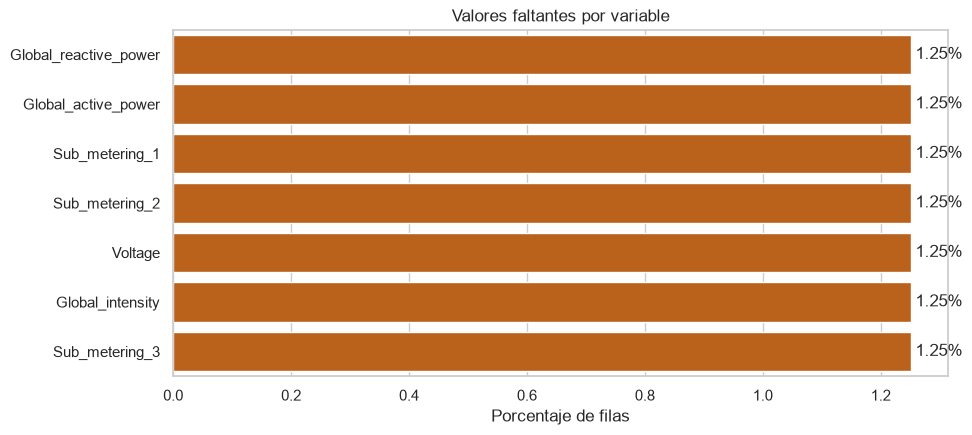

Interpretación: los faltantes se conservan como NA. La proporción se reporta por variable antes de calcular cualquier estadístico, en lugar de convertirlos artificialmente en ceros.


In [3]:
missing = raw.isna().sum().to_frame("faltantes")
missing["porcentaje"] = missing["faltantes"].div(len(raw)).mul(100)
missing = missing.sort_values("faltantes", ascending=False)
display(missing)

fig, ax = plt.subplots(figsize=(10, 4.5))
shown = missing.loc[missing.faltantes.gt(0)]
sns.barplot(data=shown.reset_index(names="variable"), x="porcentaje", y="variable", ax=ax, color="#D55E00")
ax.set(title="Valores faltantes por variable", xlabel="Porcentaje de filas", ylabel="")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)
plt.show()

print(
    "Interpretación: los faltantes se conservan como NA. La proporción se reporta por variable "
    "antes de calcular cualquier estadístico, en lugar de convertirlos artificialmente en ceros."
)

## 3. Limpieza analítica y variables temporales derivadas

Las columnas originales no se sobrescriben. La etiqueta `tipo_dia` y la franja permiten comparaciones categóricas; `other_active_energy_wh` sigue exactamente la relación indicada por UCI: `(Global_active_power × 1000 / 60) − Sub_metering_1 − Sub_metering_2 − Sub_metering_3`. Sus unidades son Wh por minuto.

Según la documentación oficial de UCI, los tres submedidores representan **grupos de consumo**, no medición individual de cada aparato: `Sub_metering_1` corresponde principalmente a cocina, `Sub_metering_2` a un grupo de lavandería/refrigeración/iluminación y `Sub_metering_3` a calentador eléctrico de agua y aire acondicionado. Por ello, el análisis interpreta **componentes o grupos de uso**, sin atribuir causalidad a un aparato específico.

In [4]:
df = raw.copy()
df["hora"] = df.timestamp.dt.hour
df["fecha"] = df.timestamp.dt.normalize()
df["dia_semana"] = pd.Categorical(
    df.timestamp.dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)
df["tipo_dia"] = np.where(df.timestamp.dt.dayofweek >= 5, "Fin de semana", "Laborable")
df["mes"] = df.timestamp.dt.to_period("M").astype(str)
df["franja"] = pd.cut(
    df["hora"], bins=[-1, 5, 11, 17, 23],
    labels=["Madrugada (0–5)", "Mañana (6–11)", "Tarde (12–17)", "Noche (18–23)"],
)
df["other_active_energy_wh"] = (
    df["Global_active_power"] * 1000 / 60
    - df["Sub_metering_1"] - df["Sub_metering_2"] - df["Sub_metering_3"]
)

# Hora válida: al menos 45 mediciones válidas de potencia; evita rellenar los huecos.
hourly = (
    df.set_index("timestamp")
      .resample("h")
      .agg(
          global_active_power_kw=("Global_active_power", "mean"),
          minutos_validos=("Global_active_power", "count"),
          voltage_v=("Voltage", "mean"),
          intensity_a=("Global_intensity", "mean"),
      )
)
hourly["es_hora_valida"] = hourly["minutos_validos"] >= 45
hourly.loc[~hourly["es_hora_valida"], ["global_active_power_kw", "voltage_v", "intensity_a"]] = np.nan

print(f"Horas calendario: {len(hourly):,}")
print(f"Horas que cumplen cobertura ≥45/60: {hourly.es_hora_valida.sum():,} ({hourly.es_hora_valida.mean():.2%})")
print("Se mantiene la unidad original: Global_active_power está en kW promediados por minuto.")
display(df[["timestamp", "hora", "dia_semana", "tipo_dia", "franja", "other_active_energy_wh"]].head())

Horas calendario: 34,589
Horas que cumplen cobertura ≥45/60: 34,151 (98.73%)
Se mantiene la unidad original: Global_active_power está en kW promediados por minuto.


,timestamp,hora,dia_semana,tipo_dia,franja,other_active_energy_wh
0,2006-12-16 17:24:00,17,Saturday,Fin de semana,Tarde (12–17),52.267
1,2006-12-16 17:25:00,17,Saturday,Fin de semana,Tarde (12–17),72.333
2,2006-12-16 17:26:00,17,Saturday,Fin de semana,Tarde (12–17),70.567
3,2006-12-16 17:27:00,17,Saturday,Fin de semana,Tarde (12–17),71.800
4,2006-12-16 17:28:00,17,Saturday,Fin de semana,Tarde (12–17),43.100


## 4. Medidas descriptivas: tendencia central, dispersión, posición, forma

La variable principal es **Global_active_power** (kW). Se presentan media, mediana y media recortada al 10%; la diferencia entre media y mediana ayuda a reconocer asimetría. La curtosis reportada es **exceso de curtosis**: una normal tiene valor 0 con esta convención.

In [5]:
def descriptive(series):
    x = series.dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    mean = x.mean()
    return pd.Series({
        "n válido": x.size,
        "media": mean,
        "mediana": x.median(),
        "media recortada 10%": trim_mean(x, 0.10),
        "desv. estándar": x.std(),
        "varianza": x.var(),
        "DAM respecto a la media": (x - mean).abs().mean(),
        "coef. variación (%)": 100 * x.std() / mean,
        "mínimo": x.min(),
        "Q1 (P25)": q1,
        "Q3 (P75)": q3,
        "RIQ": q3 - q1,
        "P5": x.quantile(0.05),
        "P95": x.quantile(0.95),
        "máximo": x.max(),
        "rango": x.max() - x.min(),
        "sesgo": x.skew(),
        "exceso de curtosis": x.kurt(),
    })

focus_cols = ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity",
              "Sub_metering_1", "Sub_metering_2", "Sub_metering_3", "other_active_energy_wh"]
stats = pd.DataFrame({col: descriptive(df[col]) for col in focus_cols}).T
display(stats)

power = df["Global_active_power"].dropna()
print(
    f"Interpretación automática — potencia activa: media={power.mean():.3f} kW, "
    f"mediana={power.median():.3f} kW y media recortada={trim_mean(power, 0.10):.3f} kW. "
    f"Sesgo={power.skew():.3f}; el signo positivo indica una cola hacia consumos altos."
)

,n válido,media,mediana,media recortada 10%,desv. estándar,varianza,DAM respecto a la media,coef. variación (%),mínimo,Q1 (P25),Q3 (P75),RIQ,P5,P95,máximo,rango,sesgo,exceso de curtosis
Global_active_power,"2,049,280.000",1.092,0.602,0.903,1.057,1.118,0.819,96.856,0.076,0.308,1.528,1.220,0.184,3.264,11.122,11.046,1.786,4.219
Global_reactive_power,"2,049,280.000",0.124,0.100,0.109,0.113,0.013,0.087,91.115,0.000,0.048,0.194,0.146,0.000,0.338,1.390,1.390,1.262,2.606
Voltage,"2,049,280.000",240.840,241.010,240.933,3.240,10.498,2.488,1.345,223.200,238.990,242.890,3.900,235.120,245.940,254.150,30.950,-0.327,0.725
Global_intensity,"2,049,280.000",4.628,2.600,3.832,4.444,19.753,3.397,96.038,0.200,1.400,6.400,5.000,0.800,13.800,48.400,48.200,1.849,4.601
Sub_metering_1,"2,049,280.000",1.122,0.000,0.000,6.153,37.860,2.069,548.436,0.000,0.000,0.000,0.000,0.000,1.000,88.000,88.000,5.945,35.643
Sub_metering_2,"2,049,280.000",1.299,0.000,0.266,5.822,33.896,1.931,448.359,0.000,0.000,1.000,1.000,0.000,2.000,80.000,80.000,7.091,57.907
Sub_metering_3,"2,049,280.000",6.458,1.000,5.624,8.437,71.186,7.908,130.637,0.000,0.000,17.000,17.000,0.000,19.000,31.000,31.000,0.725,-1.282
other_active_energy_wh,"2,049,280.000",9.315,5.500,7.260,9.586,91.890,6.653,102.912,-2.400,3.800,10.367,6.567,2.033,30.400,124.833,127.233,2.487,7.911


Interpretación automática — potencia activa: media=1.092 kW, mediana=0.602 kW y media recortada=0.903 kW. Sesgo=1.786; el signo positivo indica una cola hacia consumos altos.


## 5. Distribución de la potencia activa

Se grafica una muestra aleatoria reproducible para evitar saturar la visualización; los estadísticos anteriores, las tablas y las agregaciones se calculan sobre todos los minutos válidos. El boxplot usa la misma escala en kW y permite ver la posición de la mediana y los valores más alejados.

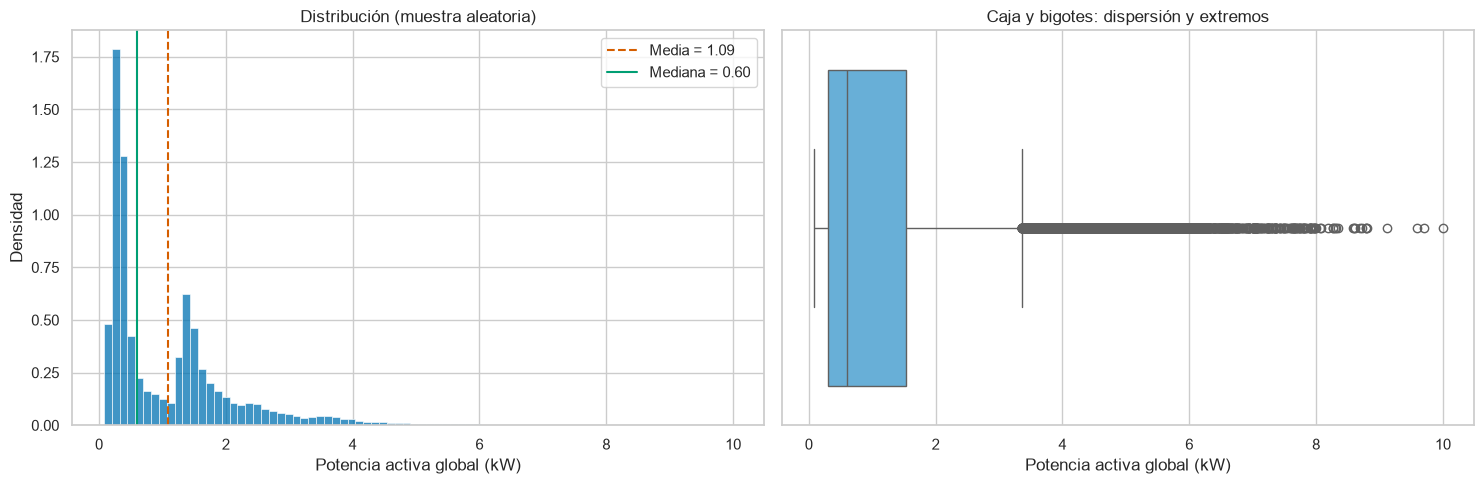

In [6]:
plot_sample = df.loc[df["Global_active_power"].notna()].sample(
    n=min(150_000, df["Global_active_power"].notna().sum()), random_state=2026
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(plot_sample["Global_active_power"], bins=80, stat="density", color="#0072B2", ax=axes[0])
axes[0].axvline(power.mean(), color="#D55E00", ls="--", label=f"Media = {power.mean():.2f}")
axes[0].axvline(power.median(), color="#009E73", ls="-", label=f"Mediana = {power.median():.2f}")
axes[0].set(xlabel="Potencia activa global (kW)", ylabel="Densidad", title="Distribución (muestra aleatoria)")
axes[0].legend()

sns.boxplot(x=plot_sample["Global_active_power"], color="#56B4E9", ax=axes[1])
axes[1].set(xlabel="Potencia activa global (kW)", title="Caja y bigotes: dispersión y extremos")
plt.tight_layout()
plt.show()

In [7]:
q1, q3 = power.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_mask = (df["Global_active_power"] < lower) | (df["Global_active_power"] > upper)
outlier_summary = pd.DataFrame({
    "Q1": [q1], "Q3": [q3], "RIQ": [iqr], "límite inferior": [lower],
    "límite superior": [upper], "minutos marcados": [outlier_mask.sum()],
    "% válido marcado": [100 * outlier_mask.sum() / power.size],
})
display(outlier_summary)
print(
    "Los minutos por encima del límite superior son observaciones inusuales bajo la regla de Tukey, "
    "no errores demostrados. Se conservan porque el objetivo es estudiar picos reales de uso eléctrico."
)

,Q1,Q3,RIQ,límite inferior,límite superior,minutos marcados,% válido marcado
0,0.308,1.528,1.220,-1.522,3.358,94907,4.631


Los minutos por encima del límite superior son observaciones inusuales bajo la regla de Tukey, no errores demostrados. Se conservan porque el objetivo es estudiar picos reales de uso eléctrico.


## 6. Patrones por hora y día: comparaciones categóricas pertinentes

Estas comparaciones convierten la marca temporal en categorías interpretables. Las bandas corresponden al intervalo intercuartílico horario; no son intervalos de confianza. La mediana se prioriza junto con la media porque la distribución es asimétrica.

In [ ]:
hourly_profile = (
    df.groupby("hora", observed=True)["Global_active_power"]
      .agg(
          media="mean",
          mediana="median",
          q1=lambda s: s.quantile(.25),
          q3=lambda s: s.quantile(.75),
          n="count"
      )
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hourly_profile.index, hourly_profile["media"], marker="o", label="Media", color="#0072B2")
ax.plot(hourly_profile.index, hourly_profile["mediana"], marker="o", label="Mediana", color="#D55E00")
ax.fill_between(
    hourly_profile.index,
    hourly_profile.q1,
    hourly_profile.q3,
    alpha=.20,
    color="#56B4E9",
    label="RIQ"
)
ax.set(
    xticks=range(24),
    xlabel="Hora del día",
    ylabel="Potencia activa global (kW)",
    title="Perfil diario de consumo por hora"
)
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

hourly_by_type = (
    df.groupby(["hora", "tipo_dia"], observed=True)["Global_active_power"]
      .mean()
      .unstack("tipo_dia")
      .reindex(columns=["Laborable", "Fin de semana"])
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hourly_by_type.index, hourly_by_type["Laborable"], marker="o", label="Laborable", color="#0072B2")
ax.plot(hourly_by_type.index, hourly_by_type["Fin de semana"], marker="o", label="Fin de semana", color="#E69F00")
ax.set(
    xticks=range(24),
    xlabel="Hora del día",
    ylabel="Potencia activa global (kW)",
    title="Perfil horario por tipo de día"
)
ax.legend()
plt.tight_layout()
plt.show()

peak_hour = hourly_profile["media"].idxmax()
low_hour = hourly_profile["media"].idxmin()
print(f"La media más alta ocurre a las {peak_hour:02d}:00; la más baja, a las {low_hour:02d}:00.")
display(hourly_profile.round(3))
display(hourly_by_type.round(3))


In [ ]:
order = ["Madrugada (0–5)", "Mañana (6–11)", "Tarde (12–17)", "Noche (18–23)"]
palette = ["#56B4E9", "#E69F00", "#009E73", "#D55E00"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, tipo in zip(axes, ["Laborable", "Fin de semana"]):
    subset = plot_sample.loc[plot_sample["tipo_dia"] == tipo]
    sns.boxplot(
        data=subset,
        x="franja",
        y="Global_active_power",
        order=order,
        hue="franja",
        legend=False,
        showfliers=True,
        palette=palette,
        ax=ax
    )
    ax.set(
        xlabel="",
        ylabel="Potencia activa global (kW)" if tipo == "Laborable" else "",
        title=tipo
    )

fig.suptitle("Consumo por franja horaria y tipo de día", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

category_summary = df.groupby(["tipo_dia", "franja"], observed=True)["Global_active_power"].agg(
    n="count",
    media="mean",
    mediana="median",
    desviacion="std",
    p95=lambda s: s.quantile(.95)
)
display(category_summary.round(3))


## 7. Relaciones entre variables eléctricas y submedición

La correlación de Pearson resume asociación lineal, no causalidad. El diagrama de dispersión toma una muestra reproducible para que se pueda ver la densidad de puntos. En particular, una alta asociación entre potencia activa e intensidad es físicamente esperable, pero no implica que una variable "cause" a la otra en este análisis observacional.

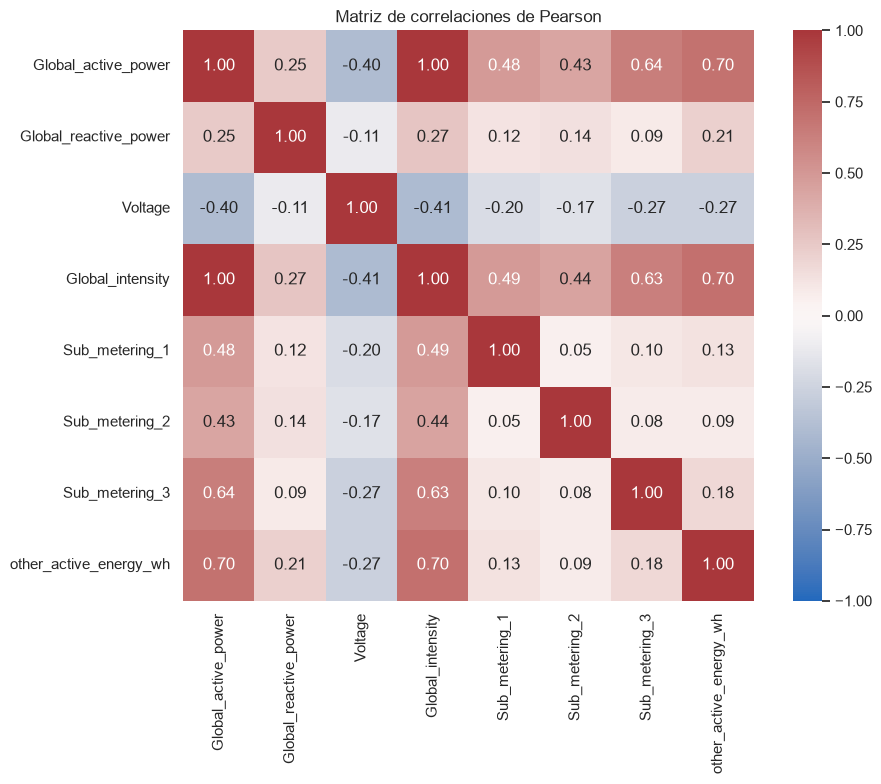

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,other_active_energy_wh
Global_active_power,1.000,0.247,-0.400,0.999,0.484,0.435,0.639,0.701
Global_reactive_power,0.247,1.000,-0.112,0.266,0.123,0.139,0.090,0.212
Voltage,-0.400,-0.112,1.000,-0.411,-0.196,-0.167,-0.268,-0.271
Global_intensity,0.999,0.266,-0.411,1.000,0.489,0.440,0.627,0.703
Sub_metering_1,0.484,0.123,-0.196,0.489,1.000,0.055,0.103,0.125
Sub_metering_2,0.435,0.139,-0.167,0.440,0.055,1.000,0.081,0.085
Sub_metering_3,0.639,0.090,-0.268,0.627,0.103,0.081,1.000,0.179
other_active_energy_wh,0.701,0.212,-0.271,0.703,0.125,0.085,0.179,1.000


In [10]:
corr_cols = ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity",
             "Sub_metering_1", "Sub_metering_2", "Sub_metering_3", "other_active_energy_wh"]
corr = df[corr_cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap="vlag", annot=True, fmt=".2f", square=True, ax=ax)
ax.set(title="Matriz de correlaciones de Pearson")
plt.tight_layout()
plt.show()
display(corr)

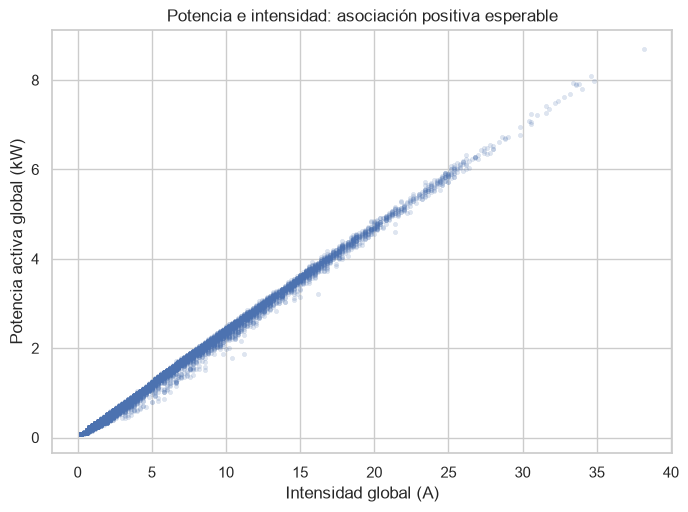

r(Potencia activa, Intensidad) = 0.999


In [11]:
scatter = plot_sample.sample(n=min(25_000, len(plot_sample)), random_state=17)
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=scatter, x="Global_intensity", y="Global_active_power", alpha=.18, s=10, edgecolor=None, ax=ax)
ax.set(xlabel="Intensidad global (A)", ylabel="Potencia activa global (kW)",
       title="Potencia e intensidad: asociación positiva esperable")
plt.show()
print(f"r(Potencia activa, Intensidad) = {corr.loc['Global_active_power', 'Global_intensity']:.3f}")

## 8. Serie agregada y composición por submedidores

La agregación por día suaviza la variación de minuto a minuto y permite observar cambios de nivel a lo largo del periodo completo. Se usa el promedio diario de potencia y se conserva la condición de cobertura aplicada a las horas. La segunda gráfica compara las medias de energía por minuto de los circuitos registrados y el consumo restante estimado.

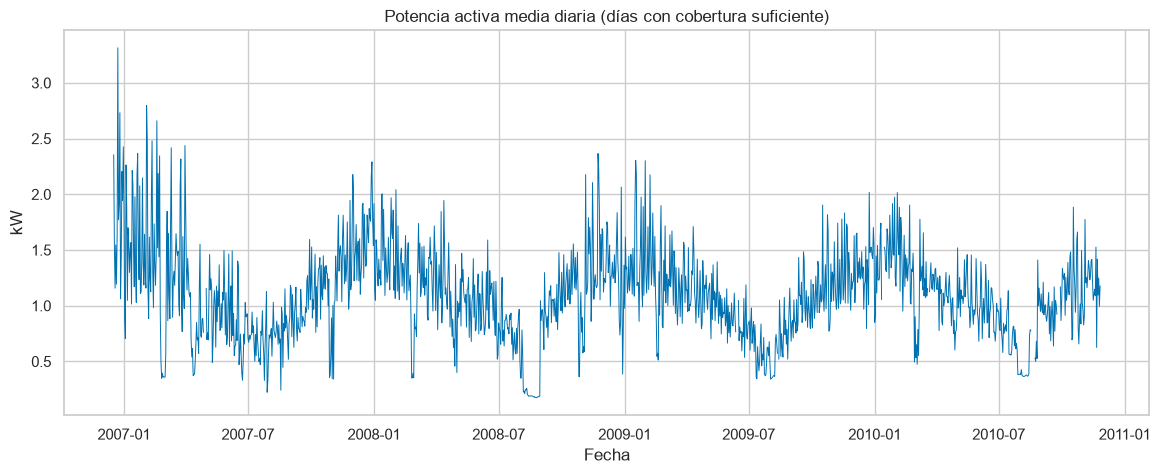

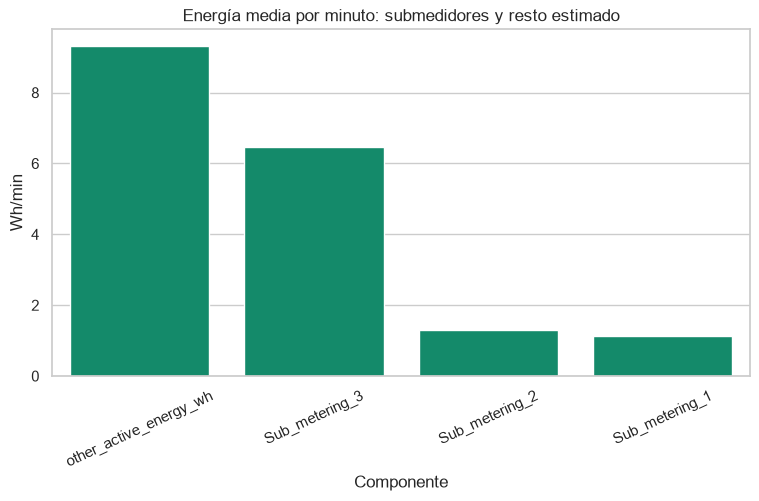

,Wh/min promedio
other_active_energy_wh,9.315
Sub_metering_3,6.458
Sub_metering_2,1.299
Sub_metering_1,1.122


In [12]:
daily = hourly.loc[hourly.es_hora_valida, "global_active_power_kw"].resample("D").agg(["mean", "count"])
daily.loc[daily["count"] < 18, "mean"] = np.nan  # día con menos de 18 horas válidas
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily["mean"], lw=.7, color="#0072B2")
ax.set(title="Potencia activa media diaria (días con cobertura suficiente)",
       xlabel="Fecha", ylabel="kW")
plt.show()

components = df[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3", "other_active_energy_wh"]].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=components.index, y=components.values, color="#009E73", ax=ax)
ax.set(title="Energía media por minuto: submedidores y resto estimado", xlabel="Componente", ylabel="Wh/min")
ax.tick_params(axis="x", rotation=25)
plt.show()
display(components.rename("Wh/min promedio").to_frame())

### 8.1 Perfil mensual y tendencia suavizada — base temporal del cartel

Para complementar el perfil horario se calcula el **promedio de `Global_active_power` por mes del año**, agrupando todos los años disponibles. También se muestran medias móviles de 7 y 30 días sobre la serie diaria. Estas gráficas ayudan a reconocer estacionalidad descriptiva; no constituyen por sí mismas una prueba causal ni un modelo de pronóstico.


In [ ]:
# Perfil mensual promedio (climatología descriptiva por mes del año)
month_labels = {1:"Ene", 2:"Feb", 3:"Mar", 4:"Abr", 5:"May", 6:"Jun",
                7:"Jul", 8:"Ago", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dic"}
monthly_profile = (
    df.assign(mes_num=df["timestamp"].dt.month)
      .groupby("mes_num", observed=True)["Global_active_power"]
      .agg(media="mean", mediana="median", n="count")
      .reindex(range(1, 13))
)
monthly_profile.index = [month_labels[i] for i in monthly_profile.index]

display(monthly_profile)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(monthly_profile.index, monthly_profile["media"], marker="o")
ax.set(title="Consumo medio mensual de potencia activa global",
       xlabel="Mes", ylabel="Potencia activa media (kW)")
plt.tight_layout(); plt.show()

# Tendencia diaria con medias móviles de 7 y 30 días
daily_series = daily["mean"]
ma7 = daily_series.rolling(7, min_periods=4).mean()
ma30 = daily_series.rolling(30, min_periods=15).mean()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_series.index, daily_series, lw=.5, alpha=.35, label="Media diaria")
ax.plot(ma7.index, ma7, lw=1.1, label="Media móvil 7 días")
ax.plot(ma30.index, ma30, lw=1.8, label="Media móvil 30 días")
ax.set(title="Serie temporal de consumo diario y medias móviles",
       xlabel="Fecha", ylabel="Potencia activa media (kW)")
ax.legend(); plt.tight_layout(); plt.show()


## 9. Análisis adicional orientado a la eficiencia energética

Para que el análisis sea más útil al público, se agregan tres lecturas cuantitativas que se derivan de los resultados ya calculados:

1. **Contraste pico–valle:** mide cuánto mayor es el consumo promedio de la hora de máxima demanda respecto a la hora de menor demanda.
2. **Efecto descriptivo del tipo de día:** compara el consumo nocturno medio de fines de semana con el de días laborables. Es una diferencia observada en esta vivienda, no un efecto causal.
3. **Composición promedio del consumo:** expresa como porcentaje la contribución media de los tres submedidores y del consumo activo residual (`other_active_energy_wh`).

También se destaca el **P95** y el **coeficiente de variación**, porque resumen mejor la intensidad de los episodios altos y la variabilidad relativa que la media por sí sola.

Indicador,Resultado
Hora de mayor consumo promedio,20:00 — 1.899 kW
Hora de menor consumo promedio,04:00 — 0.444 kW
Relación pico / valle,4.28 veces
Consumo nocturno medio — laborable,1.439 kW
Consumo nocturno medio — fin de semana,1.745 kW
Incremento nocturno fin de semana vs laborable,21.3%
P95 de Global_active_power,3.264 kW
Coeficiente de variación de Global_active_power,96.9%


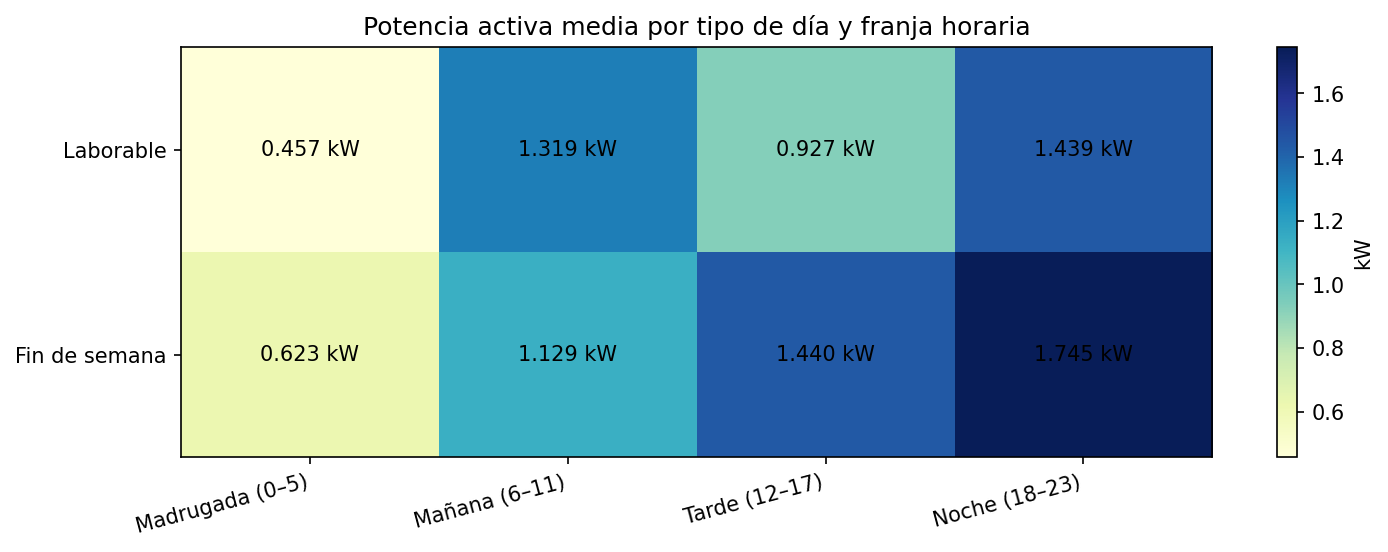

In [ ]:
# Indicadores prácticos derivados de resultados ya calculados
peak_hour = int(hourly_profile["media"].idxmax())
low_hour = int(hourly_profile["media"].idxmin())
peak_mean = float(hourly_profile.loc[peak_hour, "media"])
low_mean = float(hourly_profile.loc[low_hour, "media"])
peak_low_ratio = peak_mean / low_mean

weekday_night = float(category_summary.loc[("Laborable", "Noche (18–23)"), "media"])
weekend_night = float(category_summary.loc[("Fin de semana", "Noche (18–23)"), "media"])
weekend_night_uplift = 100 * (weekend_night / weekday_night - 1)

practical_summary = pd.DataFrame({
    "Indicador": [
        "Hora de mayor consumo promedio",
        "Hora de menor consumo promedio",
        "Relación pico / valle",
        "Consumo nocturno medio — laborable",
        "Consumo nocturno medio — fin de semana",
        "Incremento nocturno fin de semana vs laborable",
        "P95 de Global_active_power",
        "Coeficiente de variación de Global_active_power",
    ],
    "Resultado": [
        f"{peak_hour:02d}:00 — {peak_mean:.3f} kW",
        f"{low_hour:02d}:00 — {low_mean:.3f} kW",
        f"{peak_low_ratio:.2f} veces",
        f"{weekday_night:.3f} kW",
        f"{weekend_night:.3f} kW",
        f"{weekend_night_uplift:.1f}%",
        f"{stats.loc['Global_active_power', 'P95']:.3f} kW",
        f"{stats.loc['Global_active_power', 'coef. variación (%)']:.1f}%",
    ]
})
display(practical_summary)

# Mapa compacto de medias por tipo de día y franja horaria
mean_grid = (category_summary["media"].unstack("franja")
             .reindex(index=["Laborable", "Fin de semana"],
                      columns=["Madrugada (0–5)", "Mañana (6–11)", "Tarde (12–17)", "Noche (18–23)"]))
fig, ax = plt.subplots(figsize=(10, 3.8))
im = ax.imshow(mean_grid.to_numpy(), aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(mean_grid.shape[1]), mean_grid.columns, rotation=15, ha="right")
ax.set_yticks(range(mean_grid.shape[0]), mean_grid.index)
ax.set_title("Potencia activa media por tipo de día y franja horaria")
for i in range(mean_grid.shape[0]):
    for j in range(mean_grid.shape[1]):
        ax.text(j, i, f"{mean_grid.iloc[i,j]:.3f} kW", ha="center", va="center", fontsize=10)
fig.colorbar(im, ax=ax, label="kW")
plt.tight_layout(); plt.show()

,Wh/min promedio,participación_%
other_active_energy_wh,9.315,51.2
Sub_metering_3,6.458,35.5
Sub_metering_2,1.299,7.1
Sub_metering_1,1.122,6.2


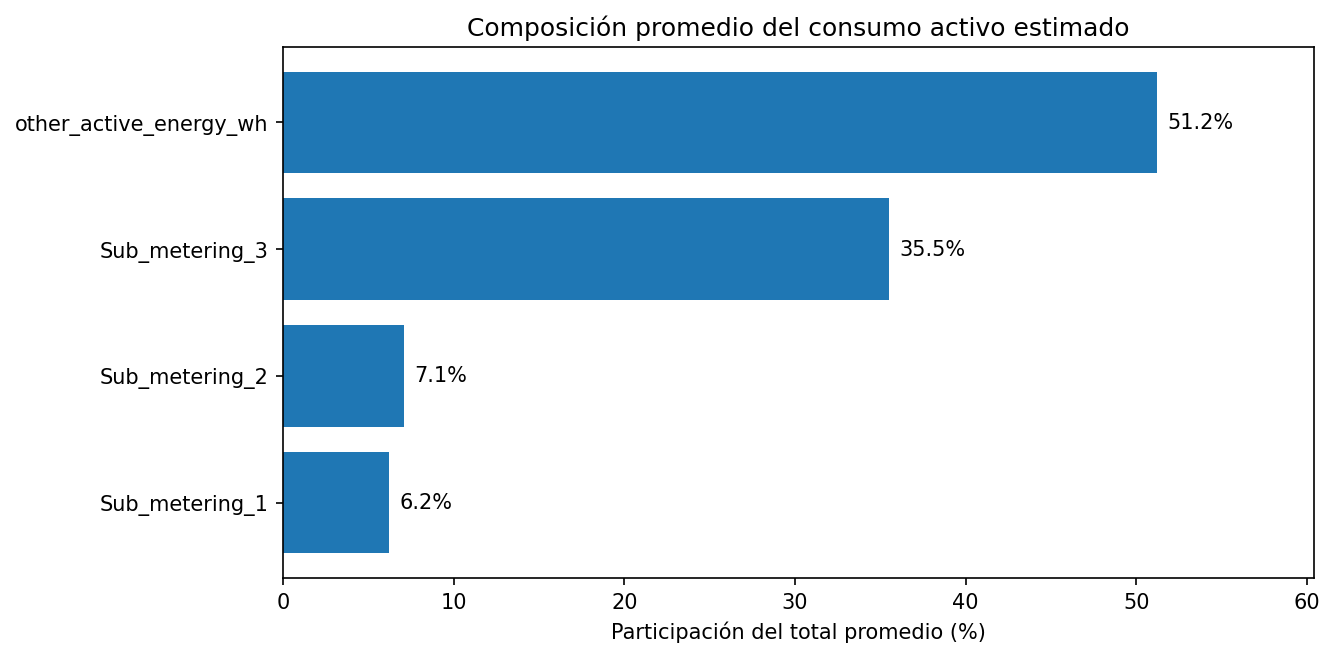

In [ ]:
# Composición promedio del consumo activo por minuto
composition = components.rename("Wh/min promedio").to_frame()
composition["participación_%"] = 100 * composition["Wh/min promedio"] / composition["Wh/min promedio"].sum()
display(composition.round({"Wh/min promedio": 3, "participación_%": 1}))

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_comp = composition.sort_values("participación_%")
ax.barh(plot_comp.index, plot_comp["participación_%"])
ax.set(title="Composición promedio del consumo activo estimado", xlabel="Participación del total promedio (%)", ylabel="")
for i, v in enumerate(plot_comp["participación_%"]):
    ax.text(v + 0.6, i, f"{v:.1f}%", va="center")
ax.set_xlim(0, max(plot_comp["participación_%"]) * 1.18)
plt.tight_layout(); plt.show()

### Interpretación de los indicadores adicionales

- La media a las **20:00 (1.899 kW)** es aproximadamente **4.28 veces** la media de las **04:00 (0.444 kW)**. Esto cuantifica la magnitud del contraste entre el pico promedio y el valle nocturno.
- Durante la noche, el fin de semana presenta una media de **1.745 kW**, frente a **1.439 kW** en días laborables: una diferencia descriptiva de aproximadamente **21.3%** en esta vivienda.
- El **P95 = 3.264 kW** significa que 95% de los minutos válidos tienen una potencia activa igual o inferior a ese valor; el **coeficiente de variación ≈ 96.9%** confirma una variabilidad relativa muy alta.
- De la energía activa promedio por minuto representada por los cuatro componentes analizados, `other_active_energy_wh` aporta aproximadamente **51.2%**, `Sub_metering_3` **35.5%**, `Sub_metering_2` **7.1%** y `Sub_metering_1` **6.2%**. `other_active_energy_wh` es un residual calculado, no un aparato; y los submedidores representan grupos de consumo.

Estos resultados sustentan recomendaciones como desplazar, **cuando sea posible**, consumos intensivos fuera del intervalo de mayor demanda. No demuestran que cambiar el horario reduzca por sí mismo el consumo total, y no deben generalizarse automáticamente a otros hogares.

> **Coherencia con el cartel:** la sección de composición usa los valores reproducibles
> `other_active_energy_wh` **51.2%**, `Sub_metering_3` **35.5%**,
> `Sub_metering_2` **7.1%** y `Sub_metering_1` **6.2%**.
> La bibliografía del cartel debe usar la referencia oficial de UCI indicada en este notebook.

## 10. Conclusiones del análisis y límites

Los resultados permiten responder la pregunta orientadora con evidencia descriptiva:

- **Forma de la distribución:** `Global_active_power` presenta asimetría positiva (sesgo = **1.786**); la media (**1.092 kW**) supera a la mediana (**0.602 kW**), coherente con una cola hacia consumos altos.
- **Variabilidad:** el coeficiente de variación es aproximadamente **96.9%** y el P95 es **3.264 kW**, por lo que el consumo es altamente variable. Los valores marcados por Tukey se conservan porque pueden representar picos reales.
- **Patrón horario:** la mayor media ocurre a las **20:00 (1.899 kW)** y la menor a las **04:00 (0.444 kW)**; el pico promedio es aproximadamente **4.28 veces** el valle.
- **Tipo de día:** durante la noche, el fin de semana registra **1.745 kW** frente a **1.439 kW** en laborables, una diferencia descriptiva de aproximadamente **21.3%**.
- **Composición:** el residual `other_active_energy_wh` representa alrededor de **51.2%** del consumo activo promedio entre los cuatro componentes considerados, y `Sub_metering_3` aproximadamente **35.5%**. Esto ayuda a priorizar dónde observar el consumo, sin identificar causalidad de aparatos individuales.
- **Asociaciones:** la correlación con `Global_intensity` es casi perfecta (**r ≈ 0.999**) y existen asociaciones moderadas con `other_active_energy_wh` y `Sub_metering_3`; la correlación no implica causalidad.

**Alcance:** los datos corresponden a una sola vivienda; describen este caso y no permiten generalizar directamente a todos los hogares. Las recomendaciones se presentan como aplicaciones prácticas plausibles de los hallazgos descriptivos, no como efectos causales demostrados.

### Referencia

Hebrail, G., & Berard, A. (2006). *Individual Household Electric Power Consumption* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C58K54